In [1]:
import pandas as pd
import numpy as np
import joblib
import shap

In [2]:
df = pd.read_csv("../data/Final_data/final_drug_dataset.csv")

xgb_demand = joblib.load("../models/demand_model.pkl")
xgb_eff = joblib.load("../models/effectiveness_model.pkl")

demand_features = joblib.load("../models/demand_features.pkl")
eff_features = joblib.load("../models/effectiveness_features.pkl")

In [3]:
df_model = df.drop(columns=['drugName', 'top_side_effects'])
df_model = pd.get_dummies(df_model, columns=['popularity'], drop_first=True)

X_d = df_model[demand_features]
X_eff = df_model[eff_features]

In [5]:
explainer_d = shap.Explainer(xgb_demand)
shap_values_d = explainer_d(X_d)

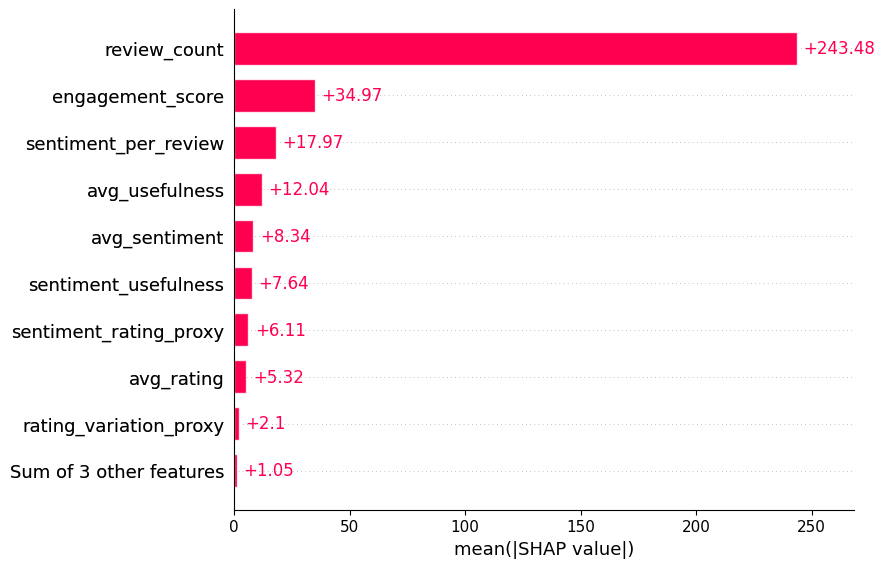

In [7]:
shap.plots.bar(shap_values_d)

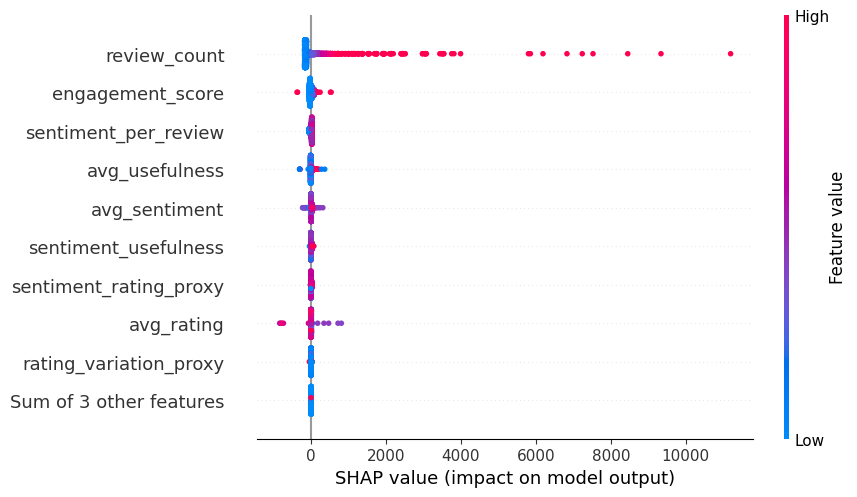

In [8]:
shap.plots.beeswarm(shap_values_d)

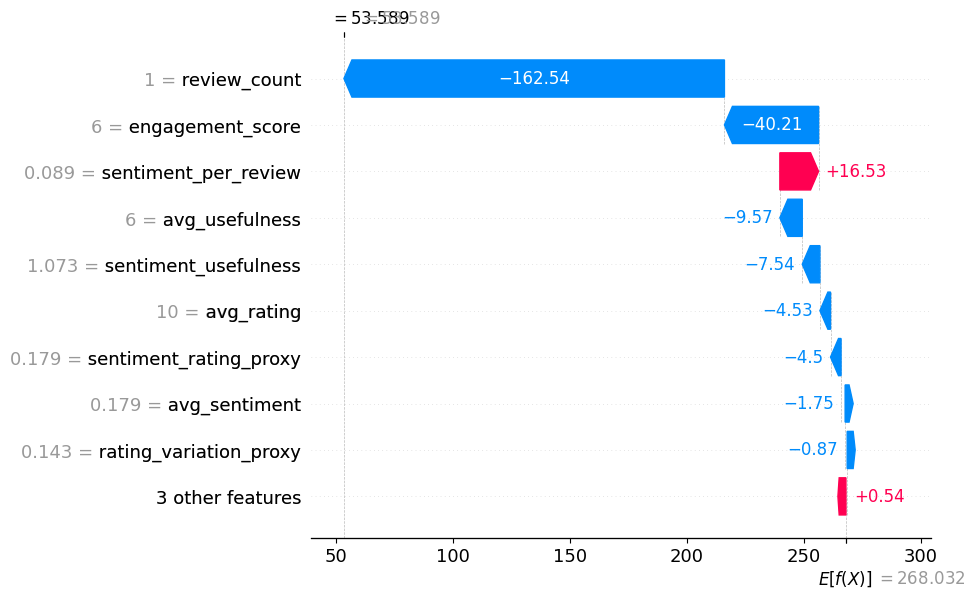

In [9]:
shap.plots.waterfall(shap_values_d[0])

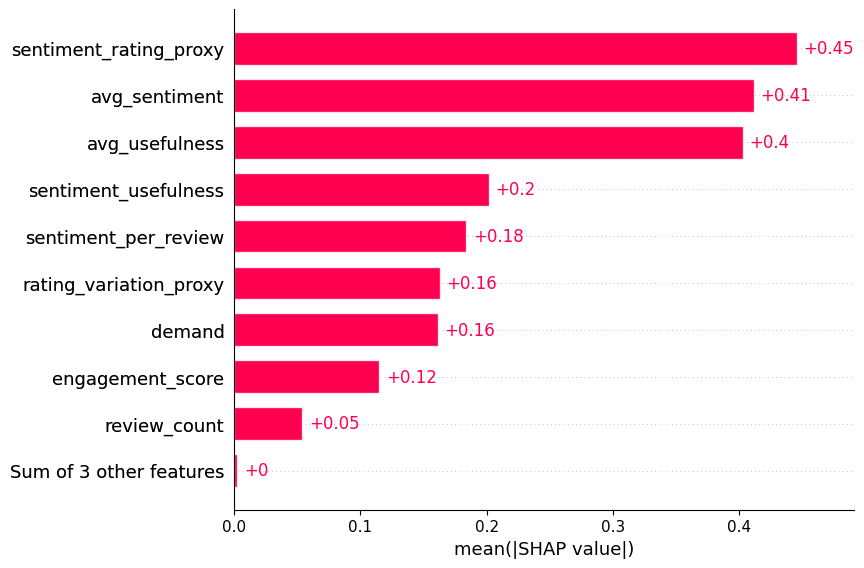

In [10]:
explainer_e = shap.Explainer(xgb_eff)
shap_values_e = explainer_e(X_eff)

shap.plots.bar(shap_values_e)